# Task 1 - Data Loading & Exploration

In [5]:
import pandas as pd
import numpy as np

df = pd.read_csv("Housing.csv")

print(" First 10 Rows ")
display(df.head(10))

print("\n Dataset Shape ")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\n Missing Values ")
print(df.isnull().sum())

 First 10 Rows 


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished



 Dataset Shape 
Rows: 545
Columns: 13

 Missing Values 
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


# Task 2 - Data Cleaning & Encoding

In [2]:
duplicate_count = df.duplicated().sum()
print("Duplicate Rows:", duplicate_count)

df = df.drop_duplicates()

print("\nMissing Values:")
print(df.isnull().sum())


text_columns = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']

for col in text_columns:
    df[col] = df[col].map({'yes': 1, 'no': 0})

df_encoded = pd.get_dummies(
    df,
    columns=['furnishingstatus'],
    drop_first=True,
    dtype=int
)

print("\nRows after cleaning:", df_encoded.shape[0])

display(df_encoded.head())

Duplicate Rows: 0

Missing Values:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Rows after cleaning: 545


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0


# Task 3 - Model Building

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train) 
lr_preds = lr_model.predict(X_test) 

print("Linear Regression Performance ")
print(f"MAE: {mean_absolute_error(y_test, lr_preds):,.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, lr_preds)):,.2f}")
print(f"R2 Score: {r2_score(y_test, lr_preds):.3f}")

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print("\n Random Forest Performance ")
print(f"MAE: {mean_absolute_error(y_test, rf_preds):,.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, rf_preds)):,.2f}")
print(f"R2 Score: {r2_score(y_test, rf_preds):.3f}")

Linear Regression Performance 
MAE: 970,043.40
RMSE: 1,324,506.96
R2 Score: 0.653

 Random Forest Performance 
MAE: 1,022,560.05
RMSE: 1,401,496.84
R2 Score: 0.611


# Task 4 - Visualizations (Graphs)

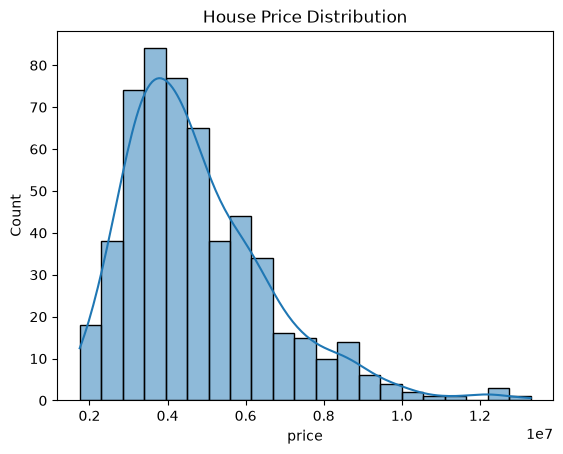

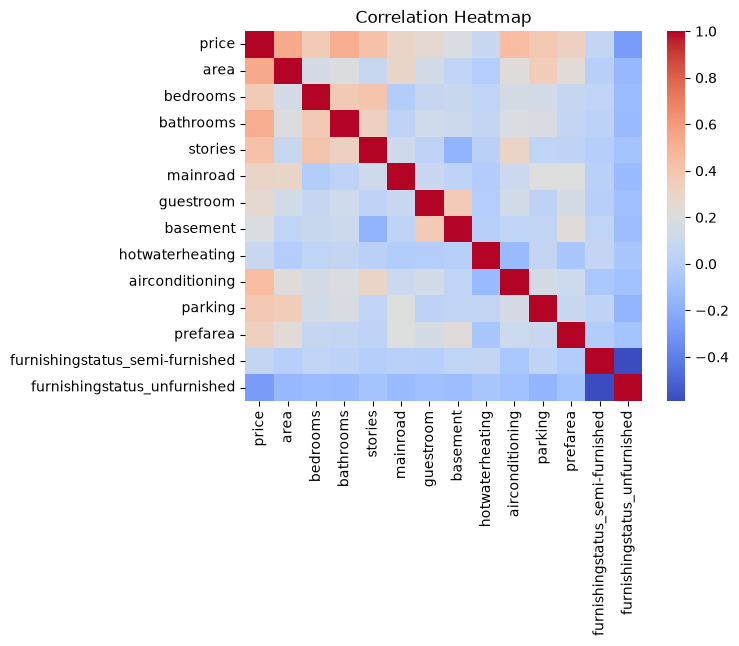

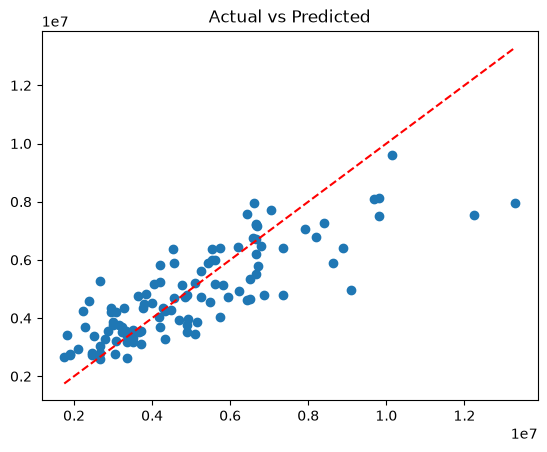

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("charts", exist_ok=True)

# Chart 1 - Histogram
sns.histplot(df_encoded['price'], kde=True)
plt.title("House Price Distribution")
plt.savefig("charts/chart1.png")
plt.show()

# Chart 2 - Heatmap
sns.heatmap(df_encoded.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.savefig("charts/chart2.png")
plt.show()

# Chart 3 - Actual vs Predicted
plt.scatter(y_test, lr_preds)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--')
plt.title("Actual vs Predicted")
plt.savefig("charts/chart3.png")
plt.show()

# Task 5 - Insights & Summary

Based on the data analysis and model training, here are the key insights:

1. Most Influential Features: The total Area (square footage) and the number of Bathrooms have the strongest positive correlation with house prices. Amenities like Air Conditioning also play a significant role.

2. Model Accuracy: In plain terms, both models perform reasonably well but are not perfect. The Linear Regression model achieved an R² score of 0.653, meaning it can explain roughly 65.3% of the variation in house prices with an average prediction error (MAE) of about ₹9.70 Lakh.

3. Surprising Discovery: Interestingly, a simple Linear Regression model slightly outperformed the complex Random Forest Regressor (R² of 0.653 vs 0.611). This indicates that house prices scale fairly linearly with structural size and amenities in this dataset. Furthermore, the number of bedrooms is less critical than the overall area—a smaller house with more rooms often costs less than a larger house with fewer rooms.

4. Business Recommendation: For a real estate company, pricing strategies and marketing campaigns should heavily prioritize highlighting the total plot area, bathroom counts, and premium features like air conditioning or parking spaces, rather than leading with just the bedroom count, as these are the actual drivers of property value.